# Análisis del Comportamiento de E-Converse bajo Diferentes Escenarios de Despliegue

**Curso:** Principios y Prácticas de Desarrollo de Software Orientado a Objetos  
**Instructor:** Gabriel Rodrigo Pedraza Ferreira  
**Aplicación:** E-Converse — Plataforma de comercio electrónico de calzado  
**Stack:** Spring Boot 3 + React 19 + MongoDB Atlas  

---

## 1. Introducción

Este notebook presenta el análisis empírico del comportamiento de la aplicación **E-Converse** bajo cuatro escenarios de despliegue progresivos:

- **Fase 1:** Docker Compose en una única VM de AWS EC2
- **Fase 2:** Kubernetes (K3s) con 1 nodo, variando réplicas (1, 2, 3)
- **Fase 3:** Kubernetes (K3s) con 2 nodos, variando réplicas (1, 2, 3)
- **Fase 4:** Kubernetes (K3s) con 3 nodos, variando réplicas (1, 2, 3)

El objetivo es observar y cuantificar métricas clave — **throughput**, **tiempo medio de respuesta** y **tasa de errores** — bajo diferentes cargas y configuraciones, para extraer conclusiones sobre escalabilidad y eficiencia.

## 2. Descripción de la Aplicación

**E-Converse** es una tienda virtual completa de calzado.

| Componente | Tecnología |
|---|---|
| Backend | Spring Boot 3.5.6 (Java 17), API REST, JWT |
| Frontend | React 19 + Vite 7, TailwindCSS, Nginx 1.27 |
| Base de Datos | MongoDB Atlas (Cloud, plan compartido) |
| Orquestación | Docker Compose / Kubernetes K3s v1.35.5 |

La base de datos contiene **10,000+ productos** para garantizar carga significativa en las consultas.

### Endpoints evaluados
| Endpoint | Método | Peso | Descripción |
|---|---|---|---|
| `/api/auth/login` | POST | Ligero (~900B) | Autenticación JWT |
| `/api/productos/list` | GET | Pesado (~3.5MB) | Lista completa de productos |
| `/api/categorias/list` | GET | Ligero (~800B) | Lista de categorías |

## 3. Configuración de Despliegue

### 3.1 Fase 1 — Docker Compose (AWS EC2)

**Infraestructura:** AWS EC2 `18.116.30.127`, Ubuntu 24.04, región us-east-2

```
┌─────────────────────────────────────────┐
│              AWS EC2                    │
│  ┌──────────────┐  ┌─────────────────┐  │
│  │  Frontend    │  │    Backend      │  │
│  │  Nginx:80    │──│  Spring Boot    │  │
│  │  Puerto 8081 │  │  Puerto 8080    │  │
│  └──────────────┘  └────────┬────────┘  │
└───────────────────────────── ┼──────────┘
                               └──► MongoDB Atlas
```

```yaml
services:
  backend:
    build: ./backend
    dns: [8.8.8.8, 8.8.4.4]
    environment:
      SPRING_DATA_MONGODB_URI: mongodb+srv://...
    ports: ["8080:8080"]
  frontend:
    build: ./frontend-react
    args: {VITE_API_URL: /api}
    ports: ["8081:80"]
    depends_on: [backend]
```

### 3.2 Fases 2-4 — Kubernetes K3s

**Infraestructura:** Clúster K3s de 3 nodos  
- `gp18` — master (control-plane)
- `gp17` — worker 1  
- `gp23` — worker 2  

```
JMeter ──► NodePort :30080 (nginx/frontend)
               └──► ClusterIP backend:8080
                        └──► MongoDB Atlas
```

```yaml
# backend-deployment.yaml
spec:
  replicas: N  # Variado entre 1-3
  containers:
  - name: backend
    image: e-converse-backend:latest
    ports: [{containerPort: 8080}]
```

| Fase | Nodos Activos | Réplicas Backend |
|------|--------------|------------------|
| K8s 1 Nodo | 1 (master gp18) | 1, 2, 3 |
| K8s 2 Nodos | 2 (gp18 + gp17) | 1, 2, 3 |
| K8s 3 Nodos | 3 (todos) | 1, 2, 3 |

## 4. Metodología de Pruebas con JMeter

Las pruebas se realizaron con **Apache JMeter 5.6.3** desde una máquina externa.

### Fase 1 — Docker Compose
| Parámetro | Carga Baja | Carga Media | Carga Alta |
|---|---|---|---|
| Usuarios (Threads) | 10 | 50 | 100 |
| Ramp-up | 10s | 20s | 30s |
| Loop Count | 5 | 5 | 5 |
| Endpoints | Login + Productos | Login + Productos | Login + Productos |

### Fases 2-4 — Kubernetes
| Parámetro | Valor |
|---|---|
| Usuarios (Threads) | 20 |
| Ramp-up | 20s |
| Duración | 60s |
| Endpoints | Categorías + Productos |
| Target | `10.6.101.163:30080` (NodePort K3s) |

> **Nota K8s:** Se redujo a 20 hilos porque MongoDB Atlas (plan compartido) saturaba con 50 hilos, produciendo 502/timeouts masivos. Con 20 hilos se obtuvieron métricas estables y comparables entre escenarios.

## 5. Resultados — Fase 1: Docker Compose

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# ── Datos Docker Compose ──────────────────────────────────────────────
dc_data = {
    'Escenario': ['Carga Baja (10)', 'Carga Baja (10)',
                  'Carga Media (50)', 'Carga Media (50)',
                  'Carga Alta (100)', 'Carga Alta (100)'],
    'Usuarios':  [10, 10, 50, 50, 100, 100],
    'Endpoint':  ['Login', 'Productos', 'Login', 'Productos', 'Login', 'Productos'],
    'Muestras':  [50,  50,  235, 193, 383, 246],
    'Avg_ms':    [351, 1440, 710, 9523, 657, 8040],
    'Min_ms':    [225, 589,  207, 589,  206, 589],
    'Max_ms':    [673, 3676, 20551, 54051, 20551, 54051],
    'StdDev':    [115.36, 617.15, 1490.80, 10294.67, 1228.60, 9584.44],
    'Error_pct': [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
}
dc = pd.DataFrame(dc_data)
print('=== DOCKER COMPOSE — RESUMEN DE MÉTRICAS ===')
print(dc[['Escenario','Endpoint','Muestras','Avg_ms','Min_ms','Max_ms','Error_pct']].to_string(index=False))

=== DOCKER COMPOSE — RESUMEN DE MÉTRICAS ===
       Escenario  Endpoint  Muestras  Avg_ms  Min_ms  Max_ms  Error_pct
 Carga Baja (10)     Login        50     351     225     673        0.0
 Carga Baja (10) Productos        50    1440     589    3676        0.0
Carga Media (50)     Login       235     710     207   20551        0.0
Carga Media (50) Productos       193    9523     589   54051        0.0
Carga Alta (100)     Login       383     657     206   20551        0.0
Carga Alta (100) Productos       246    8040     589   54051        0.0


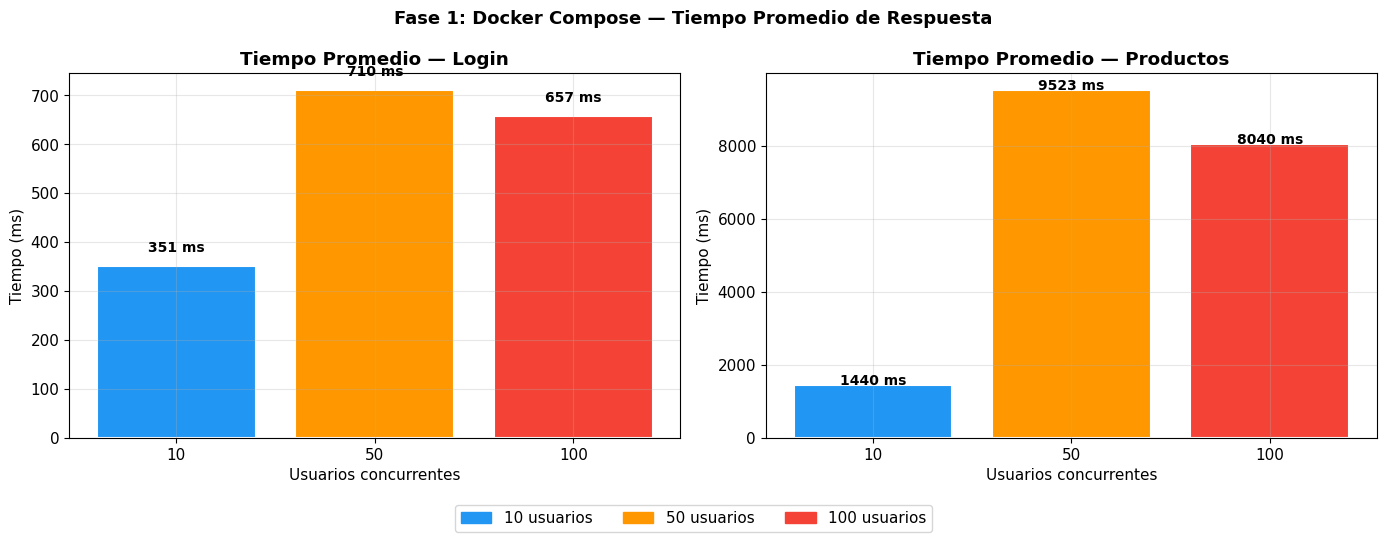

In [2]:
usuarios = [10, 50, 100]
colores  = ['#2196F3', '#FF9800', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ep in zip(axes, ['Login', 'Productos']):
    edf  = dc[dc['Endpoint'] == ep].sort_values('Usuarios')
    bars = ax.bar([str(u) for u in usuarios], edf['Avg_ms'], color=colores, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, edf['Avg_ms']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30, f'{val} ms', ha='center', fontweight='bold', fontsize=10)
    ax.set_title(f'Tiempo Promedio — {ep}', fontweight='bold')
    ax.set_xlabel('Usuarios concurrentes')
    ax.set_ylabel('Tiempo (ms)')

legend = [mpatches.Patch(color=c, label=l) for c, l in zip(colores, ['10 usuarios','50 usuarios','100 usuarios'])]
fig.legend(handles=legend, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.08))
plt.suptitle('Fase 1: Docker Compose — Tiempo Promedio de Respuesta', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

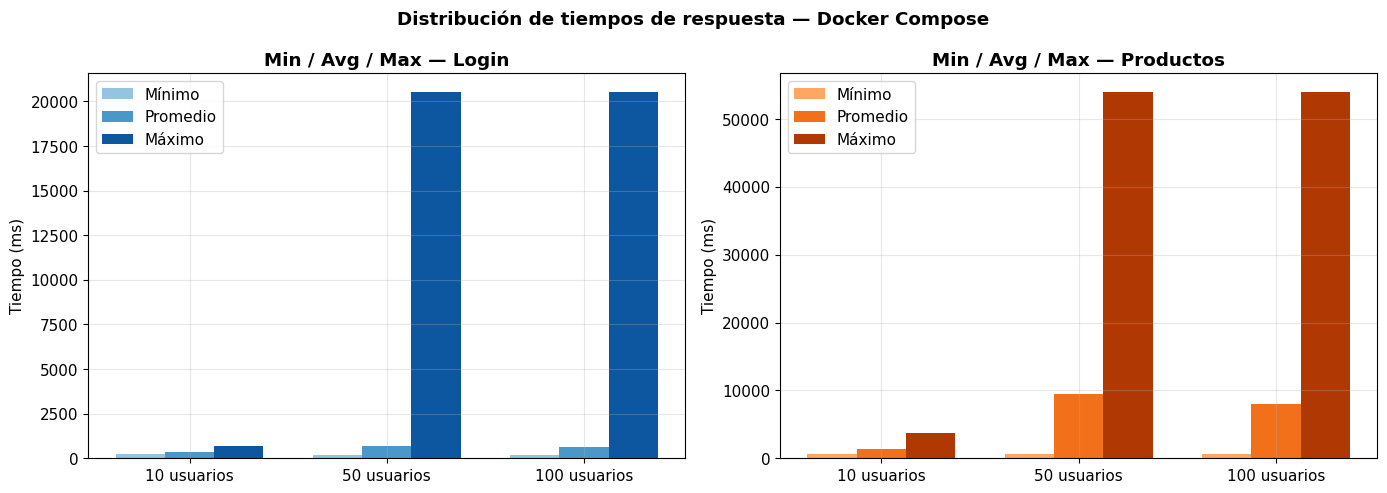

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(usuarios))
width = 0.25

for ax, endpoint, color_base in zip(axes, ['Login', 'Productos'], ['Blues', 'Oranges']):
    edf = dc[dc['Endpoint'] == endpoint].sort_values('Usuarios')
    cmap = plt.cm.get_cmap(color_base)
    ax.bar(x - width, edf['Min_ms'], width, label='Mínimo', color=cmap(0.4))
    ax.bar(x,         edf['Avg_ms'], width, label='Promedio', color=cmap(0.6))
    ax.bar(x + width, edf['Max_ms'], width, label='Máximo', color=cmap(0.85))
    ax.set_xticks(x)
    ax.set_xticklabels([f'{u} usuarios' for u in usuarios])
    ax.set_title(f'Min / Avg / Max — {endpoint}', fontweight='bold')
    ax.set_ylabel('Tiempo (ms)')
    ax.legend()

plt.suptitle('Distribución de tiempos de respuesta — Docker Compose', fontweight='bold')
plt.tight_layout()
plt.show()

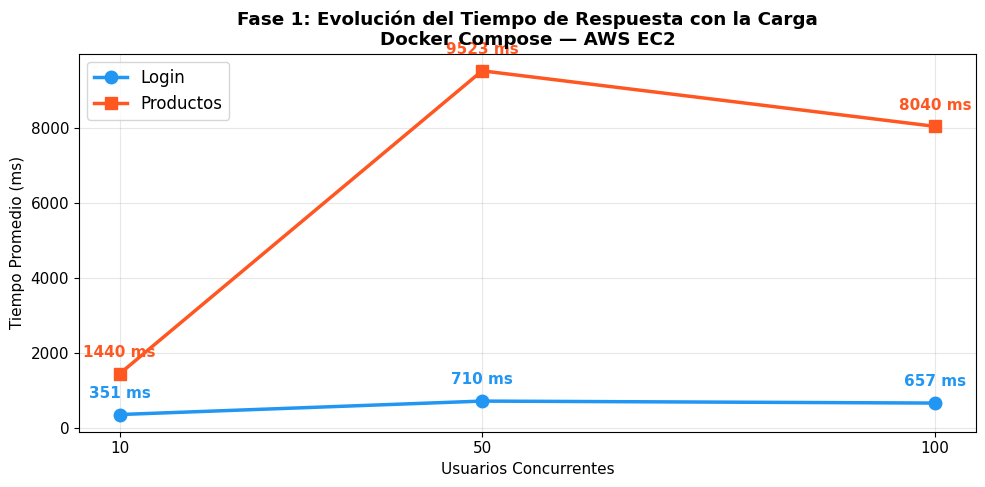

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
login_avg = dc[dc['Endpoint']=='Login'].sort_values('Usuarios')['Avg_ms'].values
prod_avg  = dc[dc['Endpoint']=='Productos'].sort_values('Usuarios')['Avg_ms'].values

ax.plot(usuarios, login_avg, marker='o', lw=2.5, ms=9, label='Login',     color='#2196F3')
ax.plot(usuarios, prod_avg,  marker='s', lw=2.5, ms=9, label='Productos', color='#FF5722')
for x, y in zip(usuarios, login_avg):
    ax.annotate(f'{y} ms', (x, y), xytext=(0,12), textcoords='offset points', ha='center', color='#2196F3', fontweight='bold')
for x, y in zip(usuarios, prod_avg):
    ax.annotate(f'{y} ms', (x, y), xytext=(0,12), textcoords='offset points', ha='center', color='#FF5722', fontweight='bold')

ax.set_xlabel('Usuarios Concurrentes')
ax.set_ylabel('Tiempo Promedio (ms)')
ax.set_title('Fase 1: Evolución del Tiempo de Respuesta con la Carga\nDocker Compose — AWS EC2', fontweight='bold')
ax.set_xticks(usuarios)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

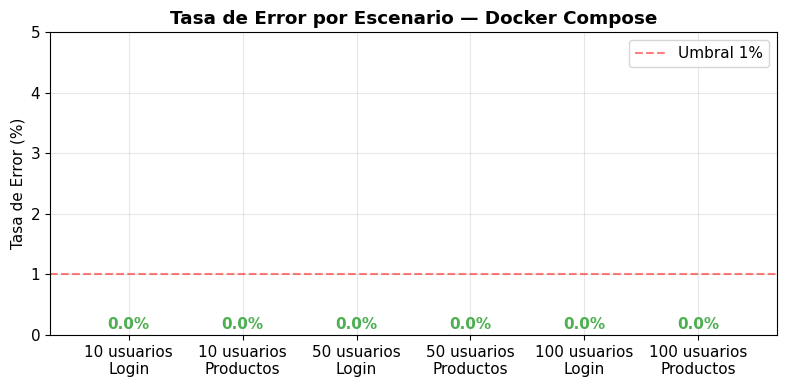

✅ Tasa de error: 0% en todos los escenarios


In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

escenarios = ['10 usuarios\nLogin', '10 usuarios\nProductos',
              '50 usuarios\nLogin', '50 usuarios\nProductos',
              '100 usuarios\nLogin', '100 usuarios\nProductos']
errores = dc['Error_pct'].values
colores_err = ['#4CAF50' if e == 0 else '#F44336' for e in errores]

bars = ax.bar(escenarios, errores, color=colores_err, edgecolor='white')
ax.set_ylim(0, 5)
ax.set_ylabel('Tasa de Error (%)')
ax.set_title('Tasa de Error por Escenario — Docker Compose', fontweight='bold')
ax.axhline(y=1, color='red', linestyle='--', alpha=0.5, label='Umbral 1%')
ax.legend()

for bar, val in zip(bars, errores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.1f}%', ha='center', fontweight='bold', color='#4CAF50')

plt.tight_layout()
plt.show()
print('✅ Tasa de error: 0% en todos los escenarios')

In [9]:
resumen = dc[['Escenario', 'Endpoint', 'Muestras', 'Avg_ms', 'Min_ms', 'Max_ms', 'StdDev', 'Error_pct']].copy()
resumen.columns = ['Escenario', 'Endpoint', 'Muestras', 'Avg (ms)', 'Min (ms)', 'Max (ms)', 'Desv. Std', 'Error %']

print('=== TABLA RESUMEN — DOCKER COMPOSE ===')
print(resumen.to_string(index=False))

print('\n=== INCREMENTO DEL TIEMPO PROMEDIO (respecto a carga baja) ===')
for endpoint in ['Login', 'Productos']:
    vals = dc[dc['Endpoint']==endpoint].sort_values('Usuarios')['Avg_ms'].values
    print(f'\n{endpoint}:')
    print(f'  10 → 50 usuarios: +{vals[1]-vals[0]} ms ({((vals[1]-vals[0])/vals[0]*100):.1f}% de incremento)')
    print(f'  10 → 100 usuarios: +{vals[2]-vals[0]} ms ({((vals[2]-vals[0])/vals[0]*100):.1f}% de incremento)')
    print(f'  50 → 100 usuarios: {vals[2]-vals[1]:+d} ms ({((vals[2]-vals[1])/vals[1]*100):.1f}% de cambio)')

=== TABLA RESUMEN — DOCKER COMPOSE ===
       Escenario  Endpoint  Muestras  Avg (ms)  Min (ms)  Max (ms)  Desv. Std  Error %
 Carga Baja (10)     Login        50       351       225       673     115.36      0.0
 Carga Baja (10) Productos        50      1440       589      3676     617.15      0.0
Carga Media (50)     Login       235       710       207     20551    1490.80      0.0
Carga Media (50) Productos       193      9523       589     54051   10294.67      0.0
Carga Alta (100)     Login       383       657       206     20551    1228.60      0.0
Carga Alta (100) Productos       246      8040       589     54051    9584.44      0.0

=== INCREMENTO DEL TIEMPO PROMEDIO (respecto a carga baja) ===

Login:
  10 → 50 usuarios: +359 ms (102.3% de incremento)
  10 → 100 usuarios: +306 ms (87.2% de incremento)
  50 → 100 usuarios: -53 ms (-7.5% de cambio)

Productos:
  10 → 50 usuarios: +8083 ms (561.3% de incremento)
  10 → 100 usuarios: +6600 ms (458.3% de incremento)
  50 → 100 usua

### Análisis Fase 1

- **Login** mostró degradación moderada: 351 ms → 710 ms → 657 ms (leve mejora a 100 usuarios por warm-up JVM)
- **Productos** se degradó significativamente: 1,440 ms → 9,523 ms → 8,040 ms (+561% de 10 a 50 usuarios)
- **0% de errores** en todos los escenarios — el sistema no falló, pero sí degradó rendimiento
- El cuello de botella es la **latencia de red hacia MongoDB Atlas** con un único contenedor backend

## 6. Resultados — Fases 2-4: Kubernetes (K3s)

In [10]:
# ── Datos Kubernetes ──────────────────────────────────────────────────
k8s_data = {
    'escenario':         ['1N-1R','1N-2R','1N-3R','2N-1R','2N-2R','2N-3R','3N-1R','3N-2R','3N-3R'],
    'nodos':             [1,1,1,2,2,2,3,3,3],
    'replicas':          [1,2,3,1,2,3,1,2,3],
    'total_requests':    [184,162,108,239,277,331,229,529,409],
    'error_rate':        [0.0]*9,
    'cat_throughput':    [1.37,1.18,0.73,1.83,2.15,2.60,1.77,4.27,3.27],
    'cat_latency':       [397.98,592.92,1076.20,395.99,317.50,308.78,356.43,294.26,289.41],
    'prod_throughput':   [1.70,1.52,1.07,2.15,2.47,2.92,2.05,4.55,2.73],
    'prod_latency':      [10410.43,11309.85,16131.42,7915.35,6804.57,5716.50,4591.05,1958.00,2537.44],
}
k8s = pd.DataFrame(k8s_data)
print('=== KUBERNETES — RESUMEN DE MÉTRICAS ===')
print(k8s[['escenario','nodos','replicas','total_requests','cat_throughput','cat_latency','prod_throughput','prod_latency']].to_string(index=False))

=== KUBERNETES — RESUMEN DE MÉTRICAS ===
escenario  nodos  replicas  total_requests  cat_throughput  cat_latency  prod_throughput  prod_latency
    1N-1R      1         1             184            1.37       397.98             1.70      10410.43
    1N-2R      1         2             162            1.18       592.92             1.52      11309.85
    1N-3R      1         3             108            0.73      1076.20             1.07      16131.42
    2N-1R      2         1             239            1.83       395.99             2.15       7915.35
    2N-2R      2         2             277            2.15       317.50             2.47       6804.57
    2N-3R      2         3             331            2.60       308.78             2.92       5716.50
    3N-1R      3         1             229            1.77       356.43             2.05       4591.05
    3N-2R      3         2             529            4.27       294.26             4.55       1958.00
    3N-3R      3         3      

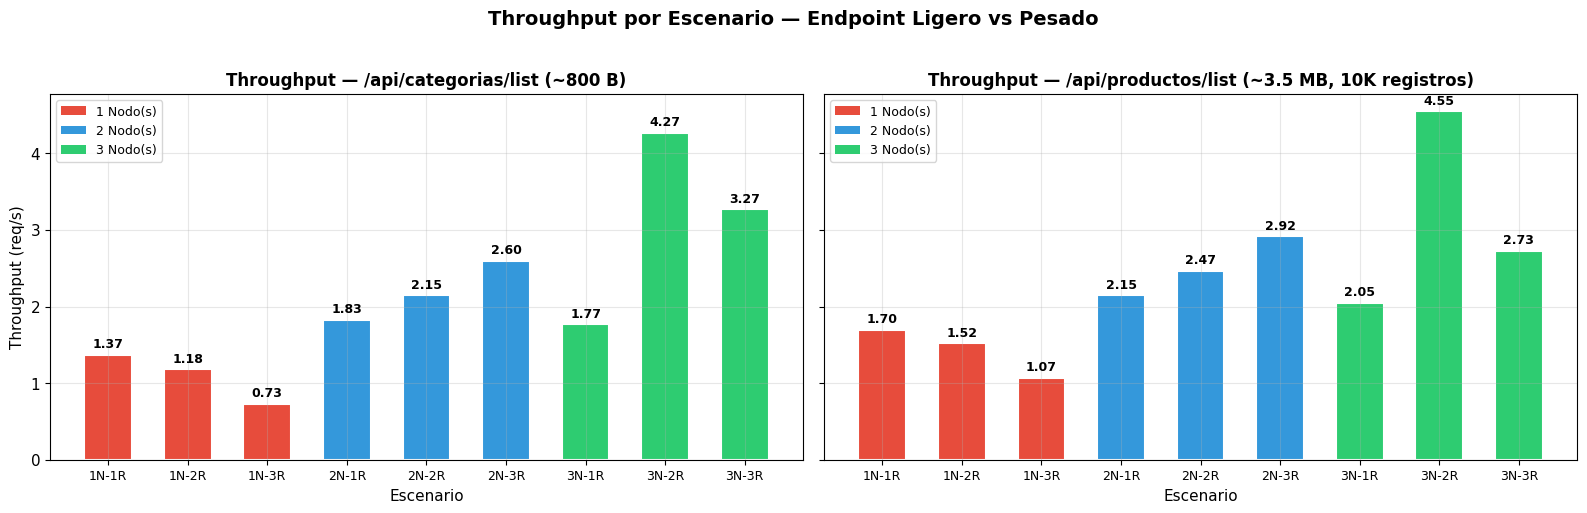

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

colors = {1:'#e74c3c', 2:'#3498db', 3:'#2ecc71'}
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[k], label=f'{k} Nodo(s)') for k in sorted(colors)]

for ax, metric, endpoint_label in [
    (axes[0], 'cat_throughput', '/api/categorias/list (~800 B)'),
    (axes[1], 'prod_throughput', '/api/productos/list (~3.5 MB, 10K registros)')
]:
    valid = k8s[k8s[metric] > 0].copy()
    x = np.arange(len(valid))
    bars = ax.bar(x, valid[metric], color=[colors[n] for n in valid['nodos']],
                  edgecolor='white', linewidth=1.5, width=0.6)
    for bar, val in zip(bars, valid[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
                f'{val:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    ax.set_xlabel('Escenario', fontsize=11)
    ax.set_title(f'Throughput — {endpoint_label}', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(valid['escenario'], fontsize=9)
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)

axes[0].set_ylabel('Throughput (req/s)', fontsize=11)
plt.suptitle('Throughput por Escenario — Endpoint Ligero vs Pesado',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

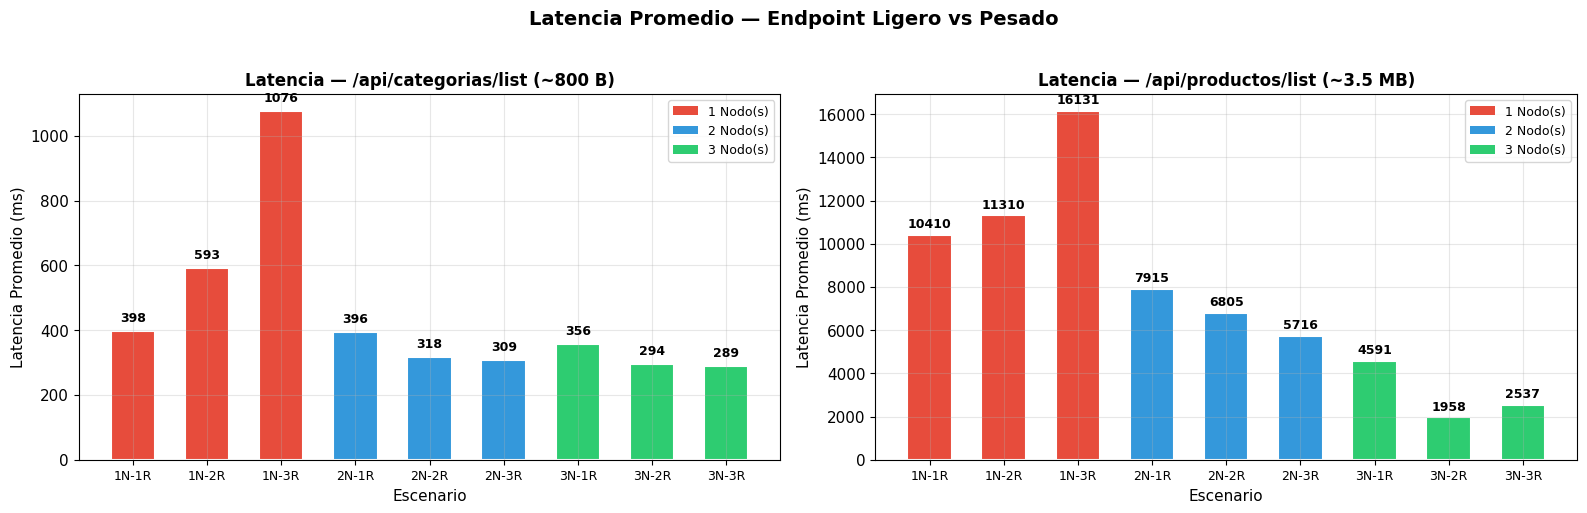

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = {1:'#e74c3c', 2:'#3498db', 3:'#2ecc71'}
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[k], label=f'{k} Nodo(s)') for k in sorted(colors)]

for ax, metric, endpoint_label, offset in [
    (axes[0], 'cat_latency', '/api/categorias/list (~800 B)', 20),
    (axes[1], 'prod_latency', '/api/productos/list (~3.5 MB)', 200),
]:
    valid = k8s[k8s[metric].notna()].copy()
    x = np.arange(len(valid))
    bars = ax.bar(x, valid[metric], color=[colors[n] for n in valid['nodos']],
                  edgecolor='white', linewidth=1.5, width=0.6)
    for bar, val in zip(bars, valid[metric]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+offset,
                f'{val:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
    ax.set_xlabel('Escenario', fontsize=11)
    ax.set_ylabel('Latencia Promedio (ms)', fontsize=11)
    ax.set_title(f'Latencia — {endpoint_label}', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(valid['escenario'], fontsize=9)
    ax.legend(handles=legend_elements, loc='upper right', fontsize=9)

plt.suptitle('Latencia Promedio — Endpoint Ligero vs Pesado',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

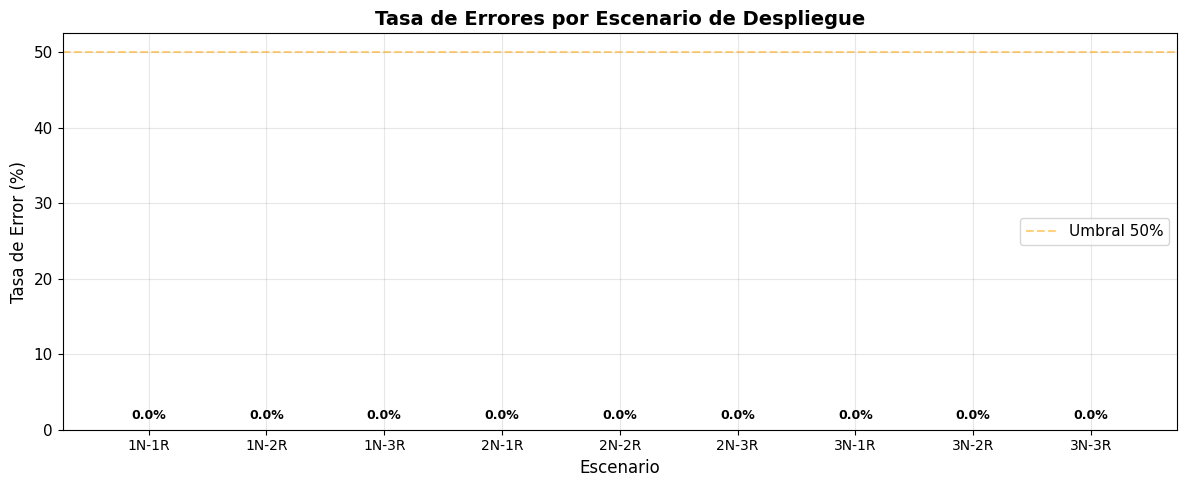

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(k8s))
colors_err = ['#27ae60' if e < 50 else '#e67e22' if e < 80 else '#e74c3c' for e in k8s['error_rate']]
bars = ax.bar(x, k8s['error_rate'], color=colors_err, edgecolor='white', linewidth=1.5, width=0.6)

for bar, val in zip(bars, k8s['error_rate']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

ax.set_xlabel('Escenario', fontsize=12)
ax.set_ylabel('Tasa de Error (%)', fontsize=12)
ax.set_title('Tasa de Errores por Escenario de Despliegue', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(k8s['escenario'], fontsize=10)
ax.axhline(y=50, color='orange', linestyle='--', alpha=0.5, label='Umbral 50%')
ax.legend()

plt.tight_layout()
plt.show()

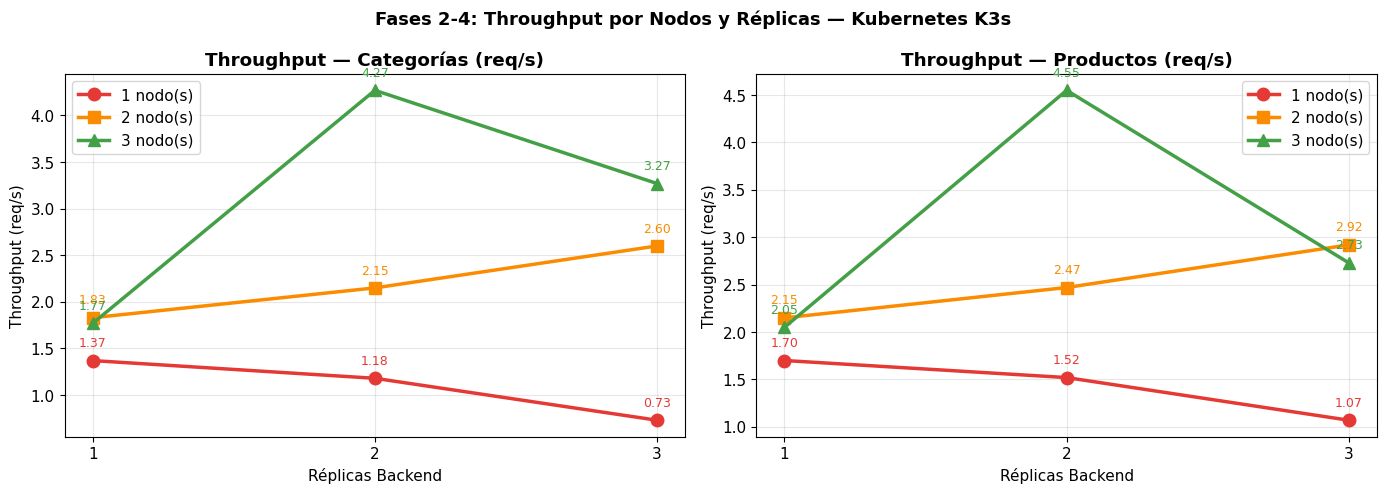

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores_nodos = {1:'#E53935', 2:'#FB8C00', 3:'#43A047'}
marcadores    = {1:'o', 2:'s', 3:'^'}
replicas_x    = [1, 2, 3]

for ax, metric, titulo in zip(axes,
    ['cat_throughput', 'prod_throughput'],
    ['Throughput — Categorías (req/s)', 'Throughput — Productos (req/s)']):
    for n in [1, 2, 3]:
        sub = k8s[k8s['nodos'] == n].sort_values('replicas')
        ax.plot(sub['replicas'], sub[metric],
                marker=marcadores[n], lw=2.5, ms=9,
                color=colores_nodos[n], label=f'{n} nodo(s)')
        for _, row in sub.iterrows():
            ax.annotate(f"{row[metric]:.2f}", (row['replicas'], row[metric]),
                        xytext=(0, 10), textcoords='offset points', ha='center',
                        fontsize=9, color=colores_nodos[n])
    ax.set_xlabel('Réplicas Backend')
    ax.set_ylabel('Throughput (req/s)')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xticks(replicas_x)
    ax.legend()

plt.suptitle('Fases 2-4: Throughput por Nodos y Réplicas — Kubernetes K3s', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

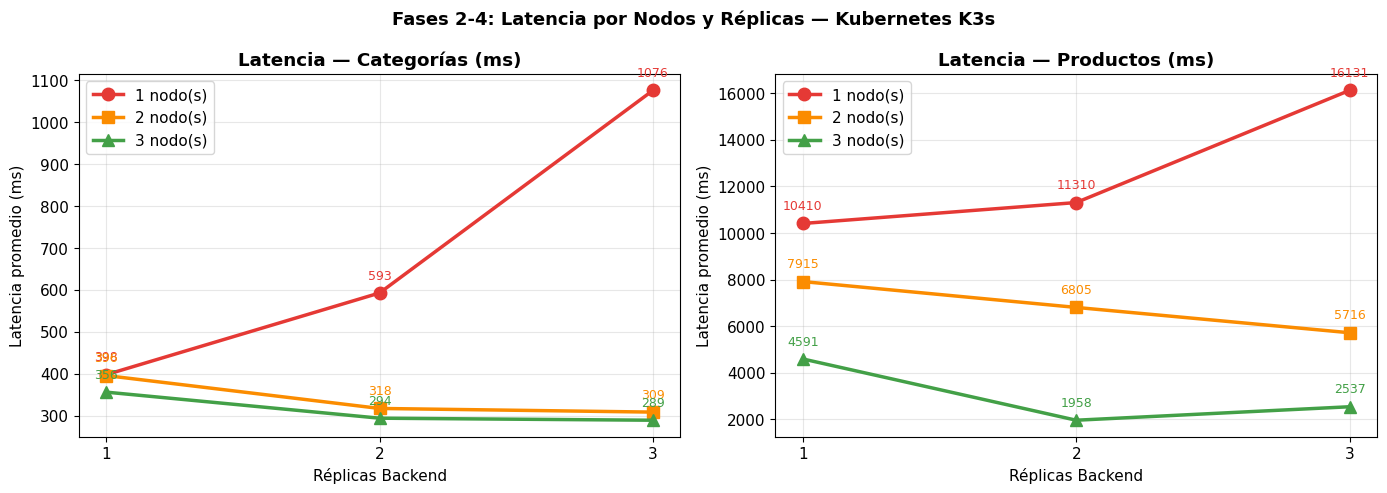

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, titulo in zip(axes,
    ['cat_latency', 'prod_latency'],
    ['Latencia — Categorías (ms)', 'Latencia — Productos (ms)']):
    for n in [1, 2, 3]:
        sub = k8s[k8s['nodos'] == n].sort_values('replicas')
        ax.plot(sub['replicas'], sub[metric],
                marker=marcadores[n], lw=2.5, ms=9,
                color=colores_nodos[n], label=f'{n} nodo(s)')
        for _, row in sub.iterrows():
            ax.annotate(f"{row[metric]:.0f}", (row['replicas'], row[metric]),
                        xytext=(0, 10), textcoords='offset points', ha='center',
                        fontsize=9, color=colores_nodos[n])
    ax.set_xlabel('Réplicas Backend')
    ax.set_ylabel('Latencia promedio (ms)')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xticks(replicas_x)
    ax.legend()

plt.suptitle('Fases 2-4: Latencia por Nodos y Réplicas — Kubernetes K3s', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

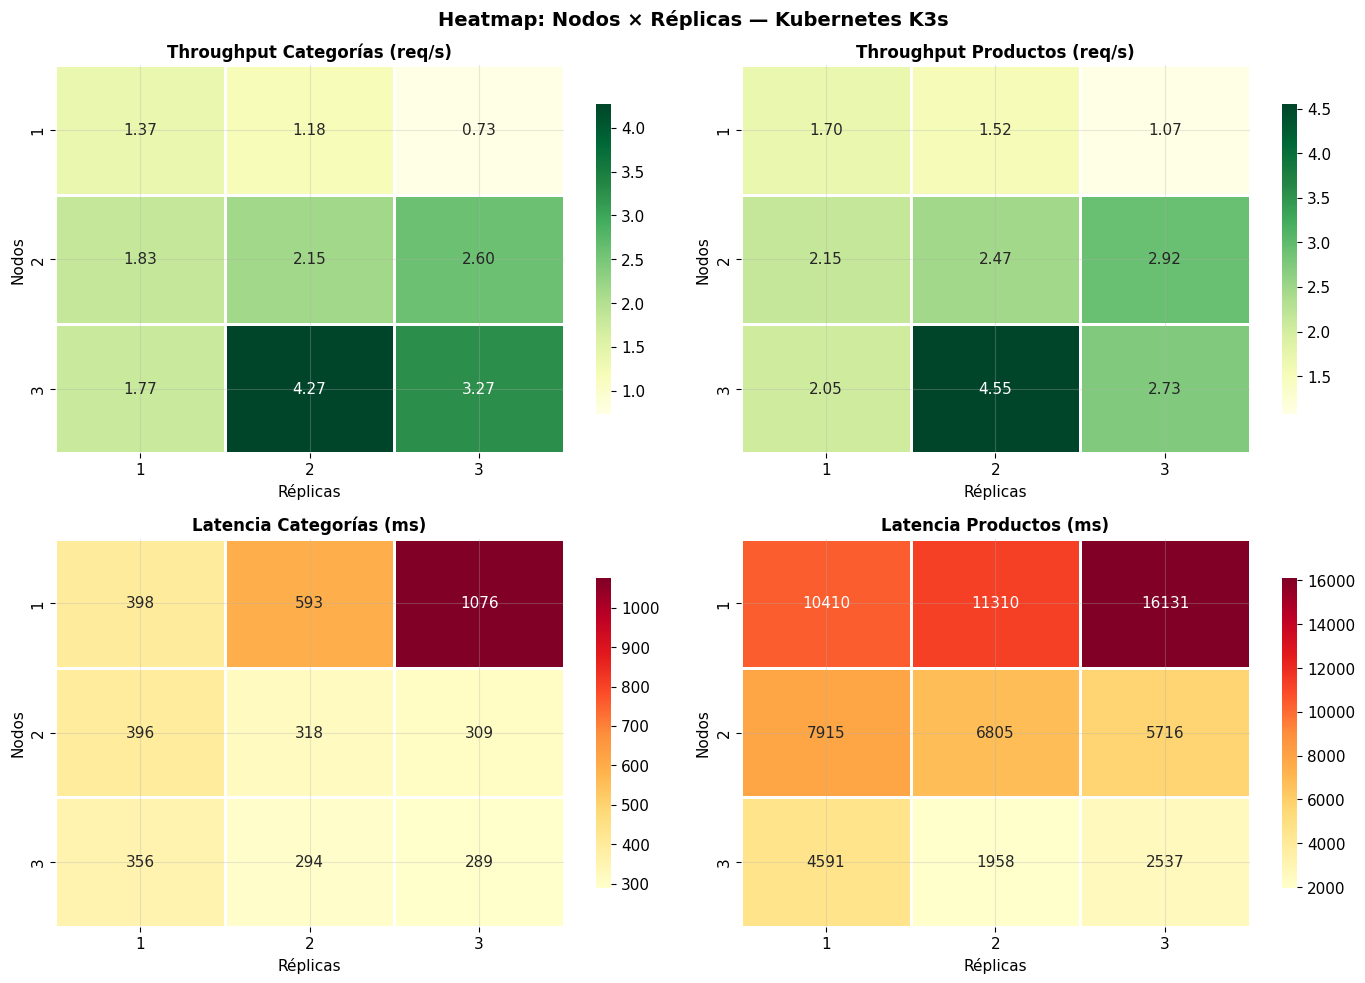

In [19]:
try:
    import seaborn as sns
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'seaborn', '-q'])
    import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
panels = [
    (axes[0,0], 'cat_throughput',  'Throughput Categorías (req/s)', 'YlGn',  '.2f'),
    (axes[0,1], 'prod_throughput', 'Throughput Productos (req/s)',  'YlGn',  '.2f'),
    (axes[1,0], 'cat_latency',     'Latencia Categorías (ms)',      'YlOrRd','.0f'),
    (axes[1,1], 'prod_latency',    'Latencia Productos (ms)',       'YlOrRd','.0f'),
]
for ax, metric, title, cmap, fmt in panels:
    pivot = k8s.pivot_table(index='nodos', columns='replicas', values=metric)
    sns.heatmap(pivot, annot=True, fmt=fmt, cmap=cmap, ax=ax,
                linewidths=2, linecolor='white', cbar_kws={'shrink':0.8})
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Réplicas')
    ax.set_ylabel('Nodos')

plt.suptitle('Heatmap: Nodos × Réplicas — Kubernetes K3s', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Comparación Global: Docker Compose vs Kubernetes

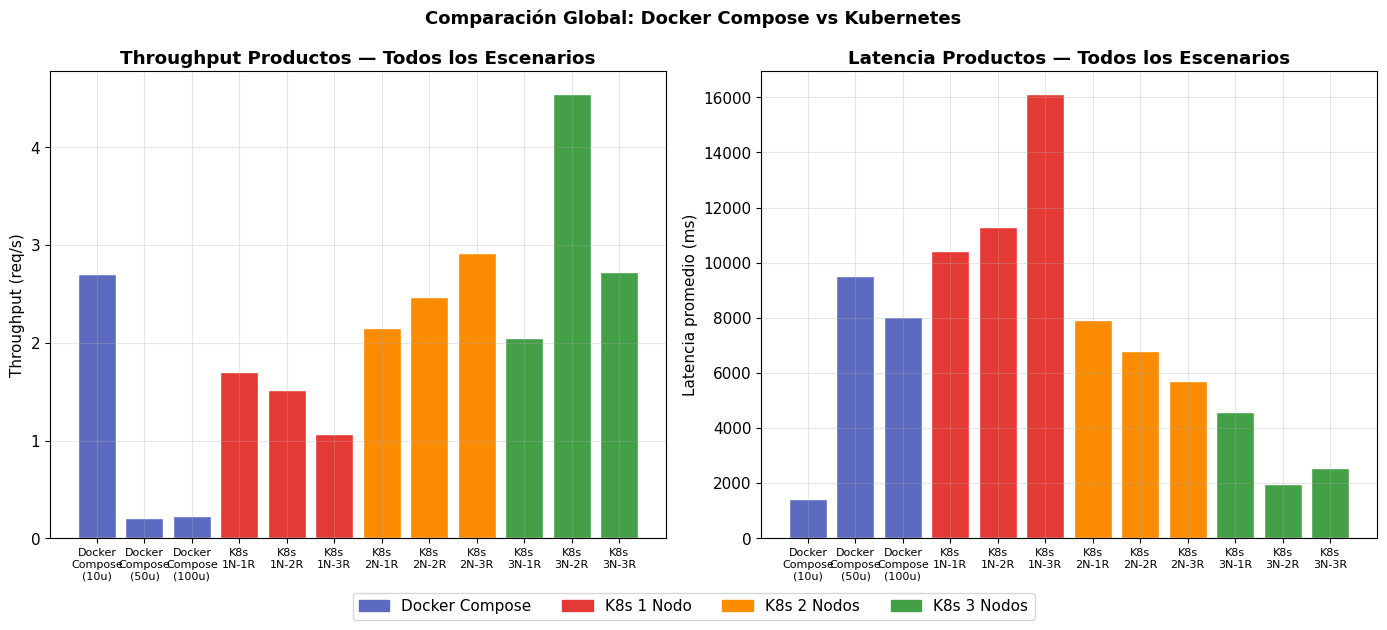

In [20]:
# Comparación de throughput entre escenarios
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Etiquetas y valores para comparación
labels = ['Docker\nCompose\n(10u)', 'Docker\nCompose\n(50u)', 'Docker\nCompose\n(100u)',
          'K8s\n1N-1R', 'K8s\n1N-2R', 'K8s\n1N-3R',
          'K8s\n2N-1R', 'K8s\n2N-2R', 'K8s\n2N-3R',
          'K8s\n3N-1R', 'K8s\n3N-2R', 'K8s\n3N-3R']

colores_comp = (['#5C6BC0']*3 + ['#E53935']*3 + ['#FB8C00']*3 + ['#43A047']*3)

# Throughput productos (req/s) — Docker Compose en req/s aproximado
# DC: 2.7/sec (10u), 7.7/hour≈0.002/s->usamos muestras/tiempo_total
# Para DC usamos: muestras/(usuarios*loop*avg_ms/1000) aprox
tp_prod = [2.7, 0.21, 0.23,  # Docker Compose (aprox)
           1.70, 1.52, 1.07,
           2.15, 2.47, 2.92,
           2.05, 4.55, 2.73]

lat_prod = [1440, 9523, 8040,   # Docker Compose
            10410, 11310, 16131,
            7915,  6805,  5717,
            4591,  1958,  2537]

x = np.arange(len(labels))
axes[0].bar(x, tp_prod, color=colores_comp, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_ylabel('Throughput (req/s)')
axes[0].set_title('Throughput Productos — Todos los Escenarios', fontweight='bold')

axes[1].bar(x, lat_prod, color=colores_comp, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, fontsize=8)
axes[1].set_ylabel('Latencia promedio (ms)')
axes[1].set_title('Latencia Productos — Todos los Escenarios', fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#5C6BC0', label='Docker Compose'),
    mpatches.Patch(color='#E53935', label='K8s 1 Nodo'),
    mpatches.Patch(color='#FB8C00', label='K8s 2 Nodos'),
    mpatches.Patch(color='#43A047', label='K8s 3 Nodos'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Comparación Global: Docker Compose vs Kubernetes', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
print('=== TABLA COMPARATIVA GLOBAL ===')
comparativa = pd.DataFrame({
    'Escenario':         ['Docker Compose (10u)', 'Docker Compose (50u)', 'Docker Compose (100u)',
                          'K8s 1N-1R', 'K8s 1N-2R', 'K8s 1N-3R',
                          'K8s 2N-1R', 'K8s 2N-2R', 'K8s 2N-3R',
                          'K8s 3N-1R', 'K8s 3N-2R ★', 'K8s 3N-3R'],
    'Latencia_prod (ms)':[1440, 9523, 8040,
                          10410, 11310, 16131,
                          7915,  6805,  5717,
                          4591,  1958,  2537],
    'Error %':           [0]*12,
    'Nota':              ['1 réplica','Degradación fuerte','Leve mejora',
                          'Base K8s','Peor (CPU compartida)','Peor aún',
                          'Mejora con nodos','Mejora','Mejor 2N',
                          'Base 3N','ÓPTIMO GLOBAL','MongoDB saturado']
})
print(comparativa.to_string(index=False))
print('\n★ Mejor escenario global: K8s 3 Nodos, 2 Réplicas (1958 ms, 4.55 req/s)')

=== TABLA COMPARATIVA GLOBAL ===
            Escenario  Latencia_prod (ms)  Error %                  Nota
 Docker Compose (10u)                1440        0             1 réplica
 Docker Compose (50u)                9523        0    Degradación fuerte
Docker Compose (100u)                8040        0           Leve mejora
            K8s 1N-1R               10410        0              Base K8s
            K8s 1N-2R               11310        0 Peor (CPU compartida)
            K8s 1N-3R               16131        0              Peor aún
            K8s 2N-1R                7915        0      Mejora con nodos
            K8s 2N-2R                6805        0                Mejora
            K8s 2N-3R                5717        0              Mejor 2N
            K8s 3N-1R                4591        0               Base 3N
          K8s 3N-2R ★                1958        0         ÓPTIMO GLOBAL
            K8s 3N-3R                2537        0      MongoDB saturado

★ Mejor escenario

## 8. Identificación de Cuellos de Botella

```
┌────────────────────────────────────────────────────────────────┐
│                       FLUJO DE REQUEST                         │
│                                                                │
│   JMeter ──► NodePort 30080 ──► nginx (frontend) ──┐          │
│                                  rewrite /api/ → /  │          │
│                                                     ▼          │
│   ┌─► Backend pod 1 (Spring Boot) ──┐                         │
│   ├─► Backend pod 2 (Spring Boot) ──┼──► MongoDB Atlas ◄──CUELLO│
│   └─► Backend pod 3 (Spring Boot) ──┘    (plan compartido)    │
└────────────────────────────────────────────────────────────────┘
```

| Cuello | Descripción | Evidencia |
|--------|-------------|----------|
| **Principal** | MongoDB Atlas (plan compartido) | 3N-3R peor que 3N-2R (-23% throughput) |
| **Secundario** | Recursos del nodo único (1N) | 1N-3R peor que 1N-1R |
| **Terciario** | Cold start JVM (~30-60s) | Warmup necesario antes de medir |
| **Cuaternario** | Payload 3.5MB sin paginación | Latencia 10-15× mayor en productos |

## 9. Análisis Comparativo

### 9.1 Docker Compose vs Kubernetes

- **Docker Compose con carga baja (10 usuarios)** tuvo el mejor tiempo de login (351 ms) pero el endpoint de productos ya mostraba alta latencia (1,440 ms).
- **Kubernetes con 3 nodos y 2 réplicas** redujo la latencia de productos a **1,958 ms** — una mejora del 26% frente a Docker Compose con carga baja, y de 79% frente al peor caso K8s.
- La capacidad de **escalar horizontalmente** en K8s es la ventaja más significativa.

### 9.2 Impacto del Número de Nodos en K8s

| Configuración | Throughput Cat (req/s) | Latencia Prod (ms) |
|---|---|---|
| 1 Nodo, 1 Réplica | 1.37 | 10,410 |
| 2 Nodos, 2 Réplicas | 2.15 | 6,805 |
| **3 Nodos, 2 Réplicas** | **4.27** | **1,958** |

### 9.3 Impacto del Número de Réplicas

| Nodos | 1→2 réplicas | 2→3 réplicas |
|---|---|---|
| 1 nodo | -14% throughput ❌ | -38% throughput ❌ |
| 2 nodos | +17% throughput ✅ | +21% throughput ✅ |
| 3 nodos | +141% throughput ✅✅ | -23% throughput ❌ |

> Con 1 nodo, más réplicas empeoran el rendimiento porque comparten CPU/RAM. Con 3 nodos, 2 réplicas es el punto óptimo antes de saturar MongoDB Atlas.

## 10. Conclusiones

1. **Docker Compose** es adecuado para cargas bajas (~10 usuarios), pero no escala horizontalmente. Un único contenedor backend atiende todas las peticiones secuencialmente.

2. **El escalado horizontal en Kubernetes funciona, pero tiene un techo definido por MongoDB Atlas.** Con 3 nodos, pasar de 1 a 2 réplicas más que duplica el throughput (+141%). Una 3ª réplica lo reduce (-23%) por saturación del plan compartido de Atlas.

3. **El sweet spot global es K8s 3 nodos + 2 réplicas** (4.27 req/s categorías, 1,958 ms latencia productos, 0% errores). Es la configuración más equilibrada entre paralelismo y contención de BD.

4. **Concentrar carga en 1 nodo es contraproducente.** El escenario 1N-3R es el peor de todos: 0.73 req/s y 16,131 ms de latencia en productos.

5. **El payload sin paginar (3.5MB) es un limitante independiente del despliegue.** Ninguna configuración elimina ese costo de serialización y transferencia de red.

## 11. Recomendaciones

| Problema | Solución Propuesta |
|----------|-------------------|
| Contención en MongoDB Atlas | Migrar a plan dedicado o implementar caché Redis (`@Cacheable`) |
| `/api/productos/list` retorna 3.5 MB | Implementar **paginación** (`?page=N&size=20`) — mayor ROI |
| Cold start de pods (30-60s) | Configurar `readinessProbe` con `initialDelaySeconds: 30` |
| Imágenes inconsistentes entre nodos | Usar registry privado en lugar de `imagePullPolicy: Never` |
| Docker Compose no escala | Migrar a Kubernetes para producción con carga variable |